# (24) save whole images

host = ```any```, device = ```any```

**Motivation**: <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

In [3]:
from utils.imgproc import do_process, xtract_patches, EyeDataset
from utils.animation import show_movie
import scipy.io as sio

## vH

In [4]:
doves = EyeDataset(device=device)
print(f"{os.listdir(doves.path)}\n{doves.imgs.shape}")

['vh_wht.npy', 'vH32', 'vHimgs.h5', 'data1024.h5', 'data1040.h5', 'vH16']
torch.Size([101, 1, 768, 1024])

In [5]:
x_wt, x_wt_cn, x_wt_cn_zs = do_process(
    stim=doves.imgs,
    device=device,
    crop_size=0,
)
x_wt_cn_zs.shape

torch.Size([101, 1, 768, 1024])

In [6]:
save_obj(
    obj=tonp(doves.imgs),
    save_dir=doves.path,
    file_name='vh_bnw',
    mode='npy',
)

save_obj(
    obj=tonp(x_wt_cn_zs),
    save_dir=doves.path,
    file_name='vh_wht',
    mode='npy',
)

[PROGRESS] 'vh_bnw.npy' saved at
/home/hadi/Datasets/DOVES

[PROGRESS] 'vh_wht.npy' saved at
/home/hadi/Datasets/DOVES

In [7]:
img_i = 16

fig, axes = create_figure(2, 2, (30, 24), sharey='row', sharex='all')

axes[0, 0].imshow(tonp(doves.imgs[img_i, 0]), cmap='Greys_r')
axes[0, 1].imshow(tonp(x_wt[img_i, 0]), cmap='Greys_r')
axes[1, 0].imshow(tonp(x_wt_cn[img_i, 0]), cmap='Greys_r')
axes[1, 1].imshow(tonp(x_wt_cn_zs[img_i, 0]), cmap='Greys_r')

plt.show()

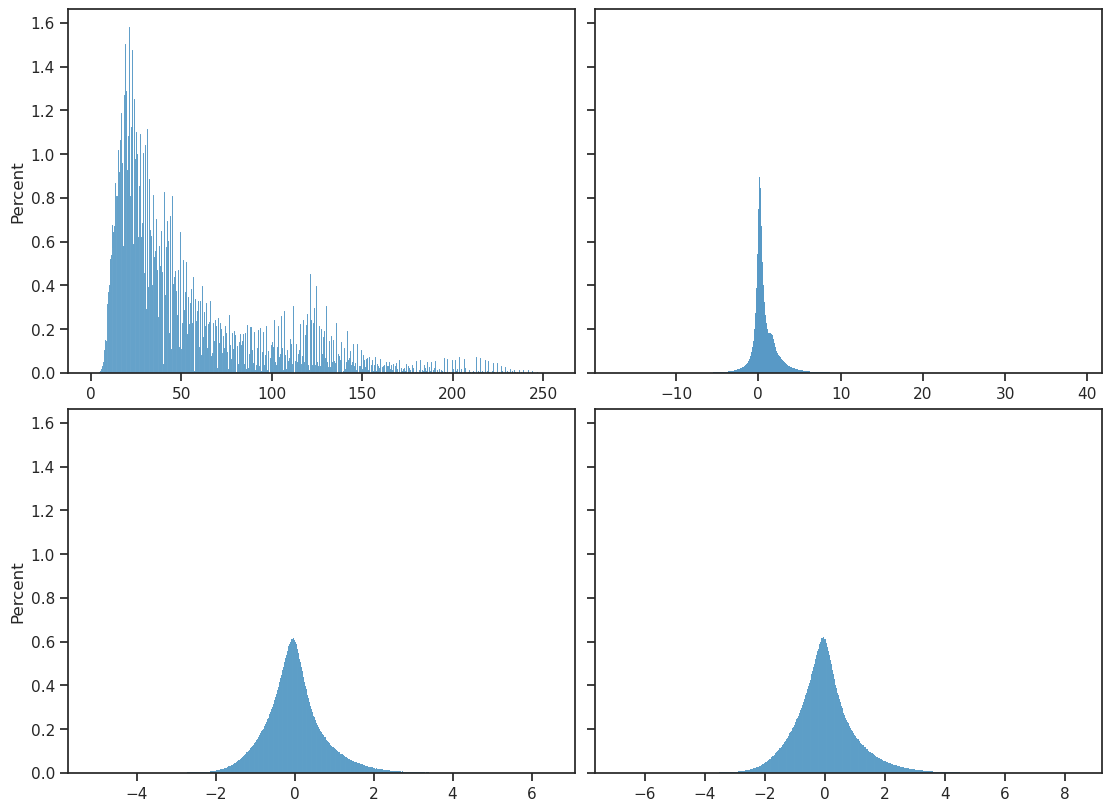

In [8]:
fig, axes = create_figure(2, 2, (11, 8), sharex='none', sharey='all')

sns.histplot(tonp(doves.imgs[:10]).ravel(), stat='percent', ax=axes[0, 0])
sns.histplot(tonp(x_wt[:10]).ravel(), stat='percent', ax=axes[0, 1])
sns.histplot(tonp(x_wt_cn[:10]).ravel(), stat='percent', ax=axes[1, 0])
sns.histplot(tonp(x_wt_cn_zs[:10]).ravel(), stat='percent', ax=axes[1, 1])

plt.show()

## Kyoto

In [7]:
root = 'Datasets/Kyoto'
root = add_home(root)

raw_dir = pjoin(root, 'raw')
files = sorted(os.listdir(raw_dir), key=alphanum_sort_key)
len(files)

62

In [8]:
imgs_color = collections.defaultdict(list)

for f in files:
    data_dict = sio.loadmat(pjoin(raw_dir, f))
    img_dim = np.asarray(data_dict['OL']).shape

    img = np.zeros([img_dim[0],img_dim[1],3])
    img[:,:,0] = np.asarray(data_dict['OL'])
    img[:,:,1] = np.asarray(data_dict['OM'])
    img[:,:,2] = np.asarray(data_dict['OS'])

    imgs_color[img_dim].append(img)

imgs_color = {
    str(k).replace(' ', ''): np.stack(v)
    for k, v in imgs_color.items()
}
imgs_bw = {k: x.mean(-1) for k, x in imgs_color.items()}

print({k: v.shape for k, v in imgs_color.items()})
print({k: v.shape for k, v in imgs_bw.items()})

{'(500,640)': (50, 500, 640, 3), '(640,500)': (12, 640, 500, 3)}

{'(500,640)': (50, 500, 640), '(640,500)': (12, 640, 500)}

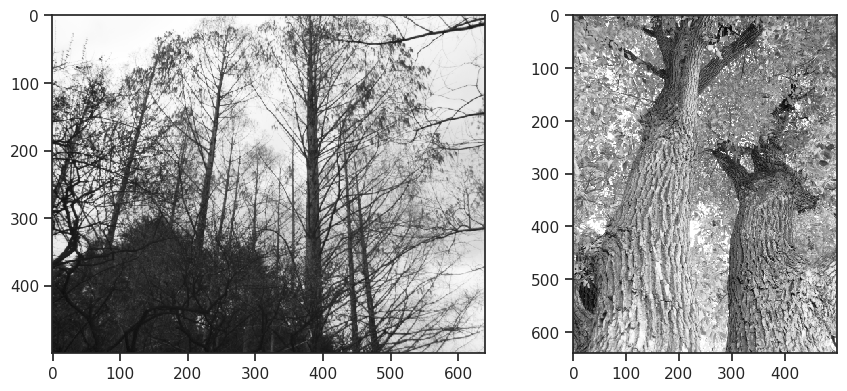

In [9]:
fig, axes = create_figure(1, 2, (9, 3.8), width_ratios=[640, 500])
axes[0].imshow(imgs_bw['(500,640)'][13], cmap='Greys_r')
axes[1].imshow(imgs_bw['(640,500)'][3], cmap='Greys_r')
plt.show()

In [26]:
kyoto_bnw = {
    k: x[:, np.newaxis]
    for k, x in imgs_bw.items()
}

kyoto_wht = {}
for k, x in kyoto_bnw.items():
    *_, x_wt_cn_zs = do_process(
        stim=torch.tensor(x, device=device, dtype=torch.float),
        device=device,
        crop_size=0,
    )
    kyoto_wht[k] = tonp(x_wt_cn_zs)

In [27]:
print({k: v.shape for k, v in imgs_color.items()})
print({k: v.shape for k, v in kyoto_bnw.items()})
print({k: v.shape for k, v in kyoto_wht.items()})

{'(500,640)': (50, 500, 640, 3), '(640,500)': (12, 640, 500, 3)}

{'(500,640)': (50, 1, 500, 640), '(640,500)': (12, 1, 640, 500)}

{'(500,640)': (50, 1, 500, 640), '(640,500)': (12, 1, 640, 500)}

In [28]:
save_dir = pjoin(root, 'processed')
print(os.listdir(save_dir))

['kyoto_bnw.npy', 'kyoto_color.npy', 'kyoto_wht.npy']

In [29]:
save_obj(
    obj=kyoto_bnw,
    save_dir=save_dir,
    file_name='kyoto_bnw',
    mode='npy',
)

save_obj(
    obj=kyoto_wht,
    save_dir=save_dir,
    file_name='kyoto_wht',
    mode='npy',
)

[PROGRESS] 'kyoto_bnw.npy' saved at
/home/hadi/Datasets/Kyoto/processed

[PROGRESS] 'kyoto_wht.npy' saved at
/home/hadi/Datasets/Kyoto/processed

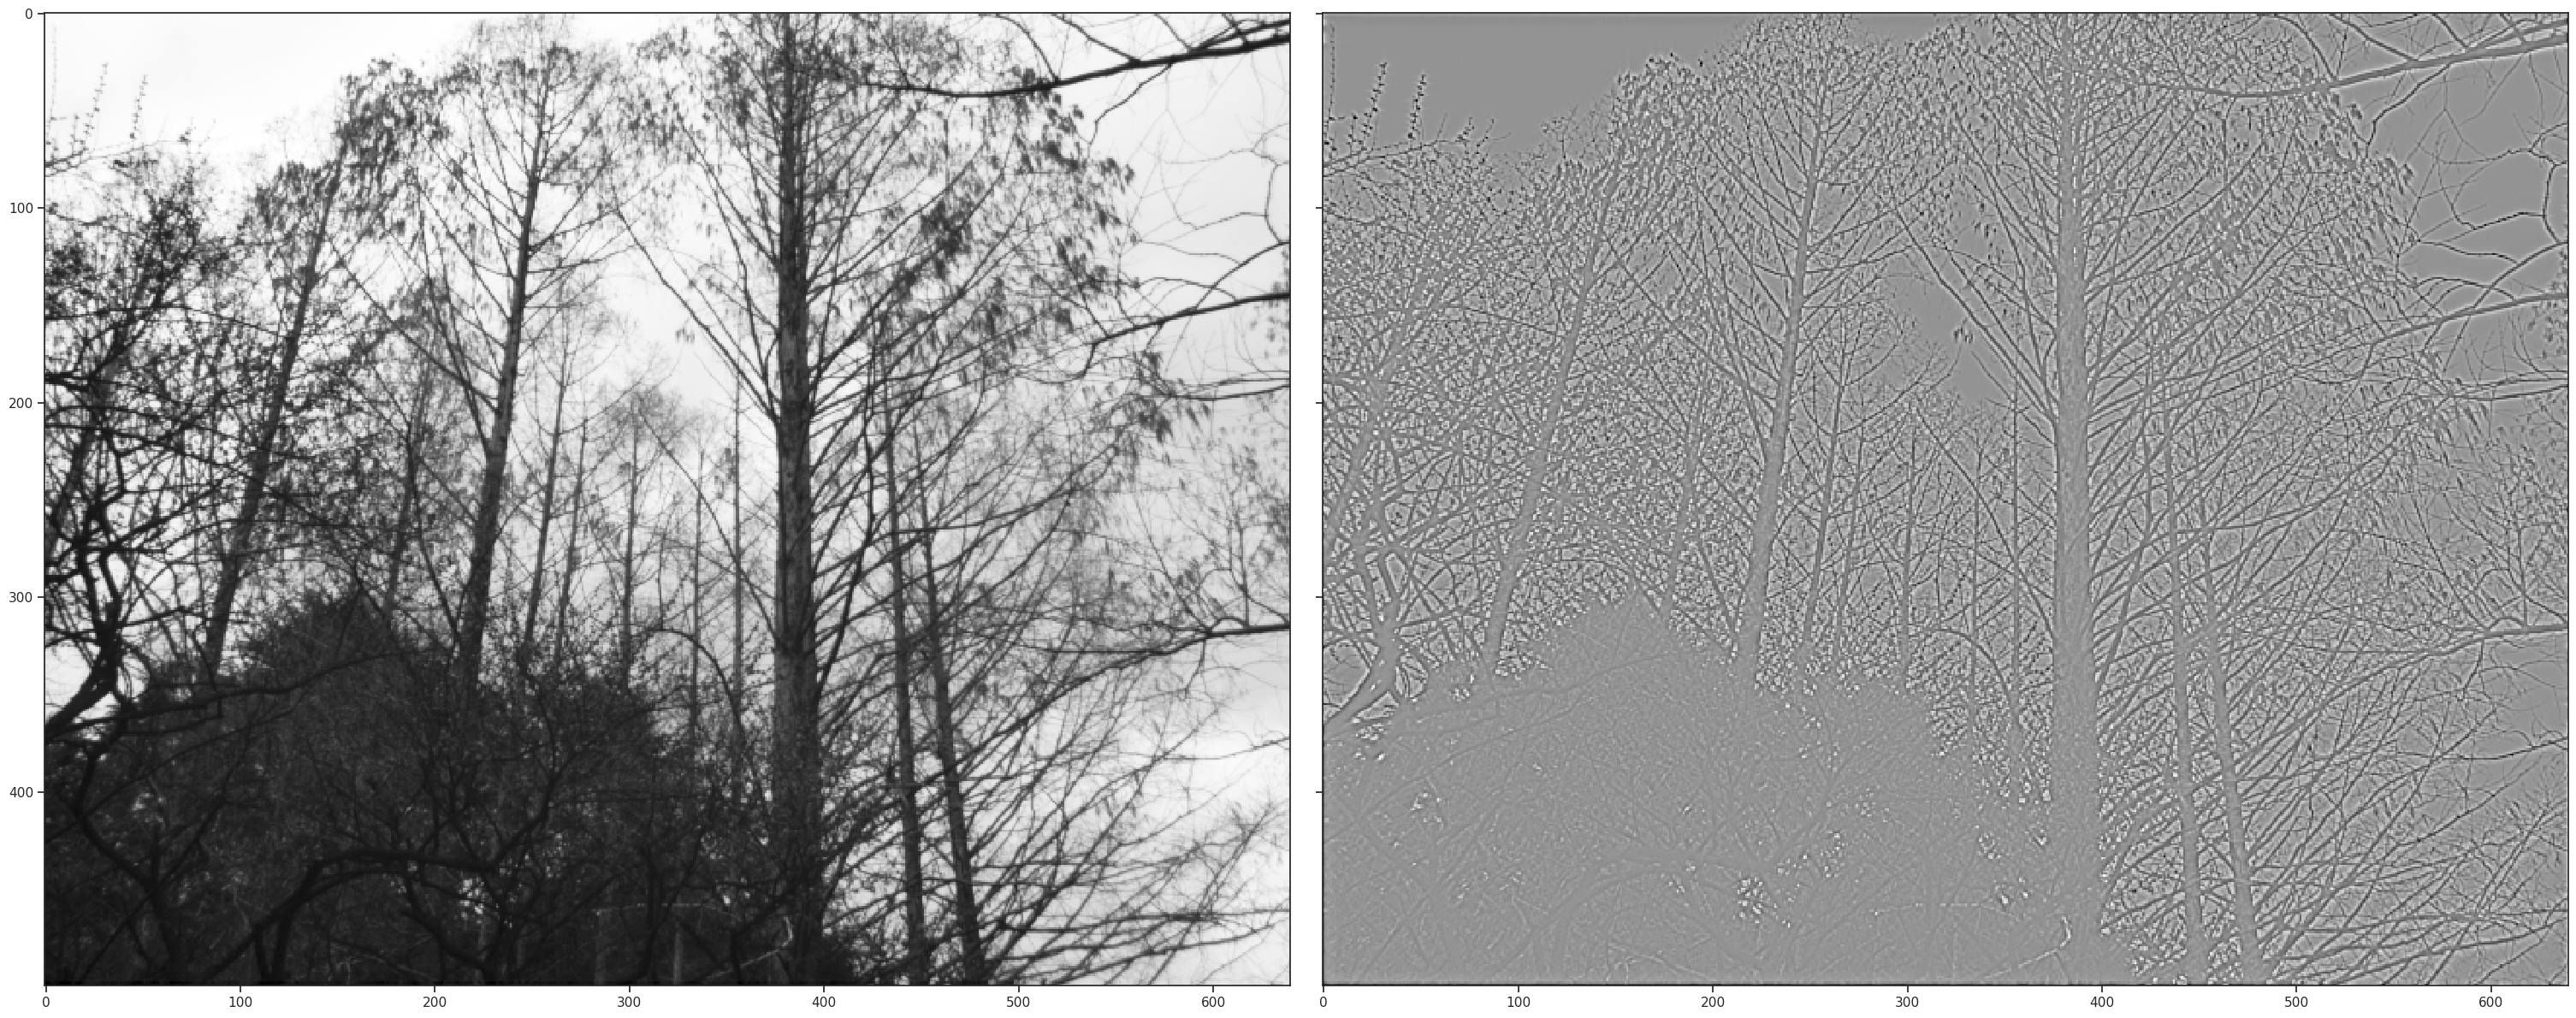

In [31]:
img_i = 13

fig, axes = create_figure(1, 2, (30, 12), sharey='row', sharex='all')

axes[0].imshow(kyoto_bnw['(500,640)'][img_i, 0], cmap='Greys_r')
axes[1].imshow(kyoto_wht['(500,640)'][img_i, 0], cmap='Greys_r')

plt.show()

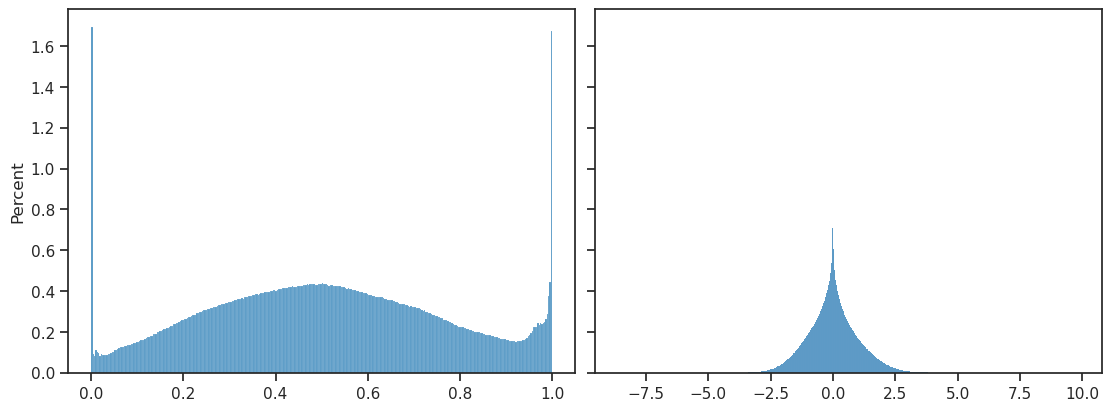

In [33]:
fig, axes = create_figure(1, 2, (11, 4), sharex='none', sharey='all')

sns.histplot(kyoto_bnw['(500,640)'].ravel(), stat='percent', ax=axes[0])
sns.histplot(kyoto_wht['(500,640)'].ravel(), stat='percent', ax=axes[1])
plt.show()